In [1]:
import scipy.io as sio

data = sio.loadmat("data/FLIC-full/examples.mat")

print(data.keys())

examples = data["examples"]

dict_keys(['__header__', '__version__', '__globals__', 'examples'])


data\FLIC-full\images\12-oclock-high-special-edition-00004151.jpg
Trying: data\FLIC-full\images\12-oclock-high-special-edition-00004151.jpg
Exists: True


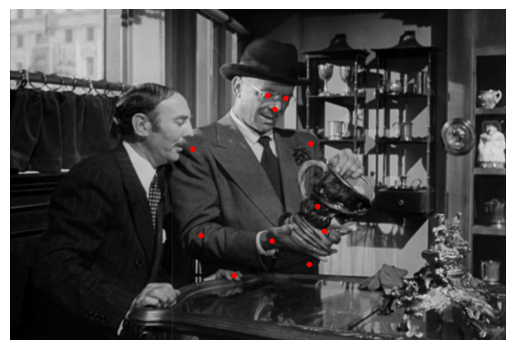

In [2]:
import os
import cv2
import matplotlib.pyplot as plt

ex = examples[0, 0]

# Decode filepath
fp = ex["filepath"][0]
if isinstance(fp, bytes):
    fp = fp.decode("utf-8")

# ALWAYS assume images live in images/
img_path = os.path.join("data", "FLIC-full", "images", fp)

print(img_path)

print("Trying:", img_path)
print("Exists:", os.path.exists(img_path))

img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

coords = ex["coords"]
for i in range(coords.shape[1]):
    x, y = coords[:, i]
    if x > 0 and y > 0:
        cv2.circle(img, (int(x), int(y)), 4, (255, 0, 0), -1)

plt.imshow(img)
plt.axis("off")
plt.show()


In [3]:
print(coords)

[[436.58776855 446.54693604 456.50613403 265.28979492 277.24081421
  380.81634521 434.59591675          nan          nan 325.04492188
           nan          nan 400.73471069 374.84082031          nan
           nan 384.80001831          nan          nan          nan
           nan          nan          nan          nan          nan
           nan          nan          nan          nan]
 [195.15625    286.796875   322.65625    203.125      328.6328125
  336.6015625  370.46875             nan          nan 386.40625
           nan          nan 129.4140625  125.4296875           nan
           nan 145.3515625           nan          nan          nan
           nan          nan          nan          nan          nan
           nan          nan          nan          nan]]


In [3]:
import numpy as np

dataset = []

num_samples = examples.shape[1]

for i in range(num_samples):
    ex = examples[0, i]

    filepath = ex['filepath'][0]

    coords = np.squeeze(ex['coords'])   # (2, 29)
    keypoints = coords.T                # (29, 2)

    dataset.append((filepath, keypoints))

In [11]:
print(dataset[0][1].shape)

(29, 2)


In [6]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

image_size = (128, 128)
num_joints = 29

images_folder = "data/FLIC-full/images"

def load_image_and_keypoints(filename, keypoints, folder=images_folder):
    filepath = os.path.join(folder, filename)
    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File does not exist: {filepath}")
    
    img = image.load_img(filepath, target_size=image_size)
    img_array = image.img_to_array(img)

    # Handle missing keypoints
    keypoints = np.nan_to_num(keypoints, nan=0.0)

    # Normalize coordinates to [0,1]
    keypoints[:, 0] /= image_size[1]  # x / width
    keypoints[:, 1] /= image_size[0]  # y / height
    
    return img_array, keypoints

In [7]:
dataset[0]

(np.str_('12-oclock-high-special-edition-00004151.jpg'),
 array([[436.58776855, 195.15625   ],
        [446.54693604, 286.796875  ],
        [456.50613403, 322.65625   ],
        [265.28979492, 203.125     ],
        [277.24081421, 328.6328125 ],
        [380.81634521, 336.6015625 ],
        [434.59591675, 370.46875   ],
        [         nan,          nan],
        [         nan,          nan],
        [325.04492188, 386.40625   ],
        [         nan,          nan],
        [         nan,          nan],
        [400.73471069, 129.4140625 ],
        [374.84082031, 125.4296875 ],
        [         nan,          nan],
        [         nan,          nan],
        [384.80001831, 145.3515625 ],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,         

In [8]:
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

X = []
y = []
filenames_list = []

for filename, keypoints in tqdm(dataset, desc="Processing Images"):
    img_array, keypoints_norm = load_image_and_keypoints(filename, keypoints, folder=images_folder)
    X.append(img_array)
    y.append(keypoints_norm)
    filenames_list.append(filename) # Store the name

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
filenames_list = np.array(filenames_list) # Convert to array for easy indexing

# Split the filenames alongside X and y
X_train, X_test, y_train, y_test, filenames_train, filenames_test = train_test_split(
    X, y, filenames_list, test_size=0.2, random_state=42
)

print(f"Total samples: {len(X)}")
print(f"Training set: {X_train.shape[0]}")
print(f"Testing set: {X_test.shape[0]}")

Processing Images: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20928/20928 [02:46<00:00, 125.72it/s]


Total samples: 20928
Training set: 16742
Testing set: 4186


In [9]:
import tensorflow as tf

model = tf.keras.Sequential([
    # Change 224 to 128
    tf.keras.layers.Input(shape=(128, 128, 3)), 
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    
    tf.keras.layers.Flatten(), 
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(58, activation='sigmoid'),
    tf.keras.layers.Reshape((29, 2))
])

In [10]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [11]:
model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=5,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/5
838/838 ━━━━━━━━━━━━━━━━━━━━ 493s 580ms/step - loss: 1.2392 - mae: 0.6022 - val_loss: 1.1890 - val_mae: 0.5899
Epoch 2/5
838/838 ━━━━━━━━━━━━━━━━━━━━ 484s 578ms/step - loss: 1.2272 - mae: 0.6089 - val_loss: 1.1545 - val_mae: 0.5554
Epoch 3/5
838/838 ━━━━━━━━━━━━━━━━━━━━ 485s 579ms/step - loss: 1.1716 - mae: 0.5663 - val_loss: 1.1545 - val_mae: 0.5554
Epoch 4/5
838/838 ━━━━━━━━━━━━━━━━━━━━ 484s 577ms/step - loss: 1.1628 - mae: 0.5591 - val_loss: 1.1545 - val_mae: 0.5554
Epoch 5/5
838/838 ━━━━━━━━━━━━━━━━━━━━ 485s 579ms/step - loss: 1.1565 - mae: 0.5538 - val_loss: 1.1545 - val_mae: 0.5554


In [12]:
# Save model
model.save("model_normalized.keras")

In [23]:
import tensorflow as tf

# Load saved model
model = tf.keras.models.load_model("model.keras")

print("Model loaded successfully")

# model.summary()

print(X_train)

# Run inference
predictions = model.predict(X_test)

# print("Prediction shape:", predictions.shape)

Model loaded successfully
[[[[153. 153. 153.]
   [159. 159. 159.]
   [162. 162. 162.]
   ...
   [173. 173. 173.]
   [171. 171. 171.]
   [161. 161. 161.]]

  [[153. 153. 153.]
   [160. 160. 160.]
   [160. 160. 160.]
   ...
   [176. 176. 176.]
   [178. 178. 178.]
   [170. 170. 170.]]

  [[151. 151. 151.]
   [154. 154. 154.]
   [155. 155. 155.]
   ...
   [172. 172. 172.]
   [182. 182. 182.]
   [171. 171. 171.]]

  ...

  [[125. 125. 125.]
   [129. 129. 129.]
   [105. 105. 105.]
   ...
   [  9.   9.   9.]
   [ 11.  11.  11.]
   [ 16.  16.  16.]]

  [[ 77.  77.  77.]
   [ 99.  99.  99.]
   [122. 122. 122.]
   ...
   [  9.   9.   9.]
   [  9.   9.   9.]
   [ 22.  22.  22.]]

  [[119. 119. 119.]
   [133. 133. 133.]
   [115. 115. 115.]
   ...
   [  9.   9.   9.]
   [  7.   7.   7.]
   [ 21.  21.  21.]]]


 [[[  2.   2.   2.]
   [  0.   0.   0.]
   [  0.   0.   0.]
   ...
   [  3.   3.   3.]
   [  0.   0.   0.]
   [  1.   1.   1.]]

  [[  1.   1.   1.]
   [  0.   0.   0.]
   [  0.   0.   0.]
  

data\FLIC-full\images\12-oclock-high-special-edition-00004151.jpg
Trying: data\FLIC-full\images\12-oclock-high-special-edition-00004151.jpg
Exists: True


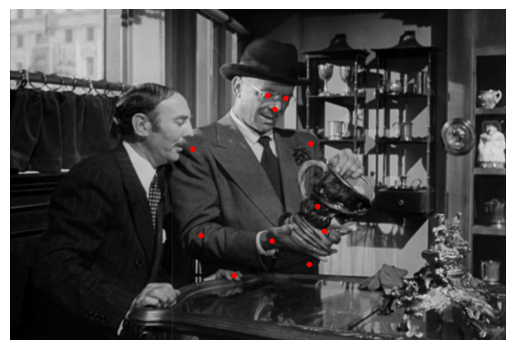

In [30]:
import os
import cv2
import matplotlib.pyplot as plt

ex = examples[0, 0]

# Decode filepath
fp = ex["filepath"][0]
if isinstance(fp, bytes):
    fp = fp.decode("utf-8")

# ALWAYS assume images live in images/
img_path = os.path.join("data", "FLIC-full", "images", fp)

print(img_path)

print("Trying:", img_path)
print("Exists:", os.path.exists(img_path))

img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

coords = ex["coords"]
for i in range(coords.shape[1]):
    x, y = coords[:, i]
    if x > 0 and y > 0:
        cv2.circle(img, (int(x), int(y)), 4, (255, 0, 0), -1)

plt.imshow(img)
plt.axis("off")
plt.show()


In [34]:
coords

array([[436.58776855, 446.54693604, 456.50613403, 265.28979492,
        277.24081421, 380.81634521, 434.59591675,          nan,
                 nan, 325.04492188,          nan,          nan,
        400.73471069, 374.84082031,          nan,          nan,
        384.80001831,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan],
       [195.15625   , 286.796875  , 322.65625   , 203.125     ,
        328.6328125 , 336.6015625 , 370.46875   ,          nan,
                 nan, 386.40625   ,          nan,          nan,
        129.4140625 , 125.4296875 ,          nan,          nan,
        145.3515625 ,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan]])

In [35]:
dataset

[(np.str_('12-oclock-high-special-edition-00004151.jpg'),
  array([[436.58776855, 195.15625   ],
         [446.54693604, 286.796875  ],
         [456.50613403, 322.65625   ],
         [265.28979492, 203.125     ],
         [277.24081421, 328.6328125 ],
         [380.81634521, 336.6015625 ],
         [434.59591675, 370.46875   ],
         [         nan,          nan],
         [         nan,          nan],
         [325.04492188, 386.40625   ],
         [         nan,          nan],
         [         nan,          nan],
         [400.73471069, 129.4140625 ],
         [374.84082031, 125.4296875 ],
         [         nan,          nan],
         [         nan,          nan],
         [384.80001831, 145.3515625 ],
         [         nan,          nan],
         [         nan,          nan],
         [         nan,          nan],
         [         nan,          nan],
         [         nan,          nan],
         [         nan,          nan],
         [         nan,          nan],
      